In [38]:
# Install Google Meridian
!pip install google-meridian[and-cuda] -q

In [39]:
# Step 1: Check installed version
import meridian
print("Meridian version:", meridian.__version__)

# Step 2: See what's inside meridian.model
import meridian.model as mm
print(dir(mm))

Meridian version: 1.5.3
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'adstock_hill', 'context', 'eda', 'equations', 'knots', 'media', 'model', 'posterior_sampler', 'prior_distribution', 'prior_sampler', 'spec', 'transformers']


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Correct imports for Meridian 1.5.3
from meridian.model.model import Meridian
from meridian.model import spec
from meridian.data import input_data

In [41]:
print("Meridian imported successfully!")
print(Meridian)

Meridian imported successfully!
<class 'meridian.model.model.Meridian'>


In [42]:
import meridian.model.model as mm
print(dir(mm))

['MCMCOOMError', 'MCMCSamplingError', 'Mapping', 'Meridian', 'ModelFittingError', 'NotFittedModelError', 'Sequence', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '__warningregistry__', '_warn_setting_national_args', 'adstock_hill', 'az', 'backend', 'collections', 'constants', 'context', 'data', 'dataclasses', 'eda_engine', 'eda_outcome', 'eda_spec_module', 'equations', 'functools', 'joblib', 'knots', 'load_mmm', 'media', 'np', 'os', 'posterior_sampler', 'prior_distribution', 'prior_sampler', 'save_mmm', 'spec', 'tc', 'transformers', 'warnings']


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from meridian.model.model import Meridian
from meridian.model import spec
from meridian.data import input_data

print("✅ All imports successful!")
print("Meridian class:", Meridian)

✅ All imports successful!
Meridian class: <class 'meridian.model.model.Meridian'>


In [44]:
from google.colab import files
uploaded = files.upload()

Saving simulated_mmm_data_.csv to simulated_mmm_data_ (1).csv


In [45]:
import pandas as pd

df = pd.read_csv('simulated_mmm_data_.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (120, 5)

Columns: ['date', 'search_spend', 'social_spend', 'youtube_spend', 'revenue']

First 5 rows:


,date,search_spend,social_spend,youtube_spend,revenue
0,2023-01-01,11674.310819,9754.037362,16762.317487,377.435579
1,2023-01-08,12658.177130,9796.989225,16882.777119,418.282503
2,2023-01-15,12781.978307,10022.895715,16970.020461,430.120324
3,2023-01-22,12542.795573,10179.762778,16552.160495,440.068233
4,2023-01-29,13060.895723,10337.188985,17159.768056,441.234407


In [46]:
# Check for nulls and data types
print("Null values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

print("\nBasic stats:")
df.describe()

Null values:
 date             0
search_spend     0
social_spend     0
youtube_spend    0
revenue          0
dtype: int64

Data types:
 date              object
search_spend     float64
social_spend     float64
youtube_spend    float64
revenue          float64
dtype: object

Basic stats:


,search_spend,social_spend,youtube_spend,revenue
count,120.000000,120.000000,120.000000,120.000000
mean,12098.989060,9013.692221,15169.737393,443.974070
std,1075.235335,741.842831,1514.086873,21.328919
min,10101.895225,7537.752483,12427.806777,377.435579
25%,11148.172029,8344.572323,13669.588517,429.202761
50%,12174.202291,9018.501918,15427.690346,444.226589
75%,12979.724699,9645.516104,16456.994653,457.884464
max,13937.756552,10485.191767,17735.737967,488.185956


In [47]:
# Parse date column properly
df_clean = df.copy()
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values('date').reset_index(drop=True)

print("Date range:", df_clean['date'].min(), "to", df_clean['date'].max())
print("Total weeks:", len(df_clean))
df_clean.head()

Date range: 2023-01-01 00:00:00 to 2025-04-13 00:00:00
Total weeks: 120


,date,search_spend,social_spend,youtube_spend,revenue
0,2023-01-01,11674.310819,9754.037362,16762.317487,377.435579
1,2023-01-08,12658.177130,9796.989225,16882.777119,418.282503
2,2023-01-15,12781.978307,10022.895715,16970.020461,430.120324
3,2023-01-22,12542.795573,10179.762778,16552.160495,440.068233
4,2023-01-29,13060.895723,10337.188985,17159.768056,441.234407


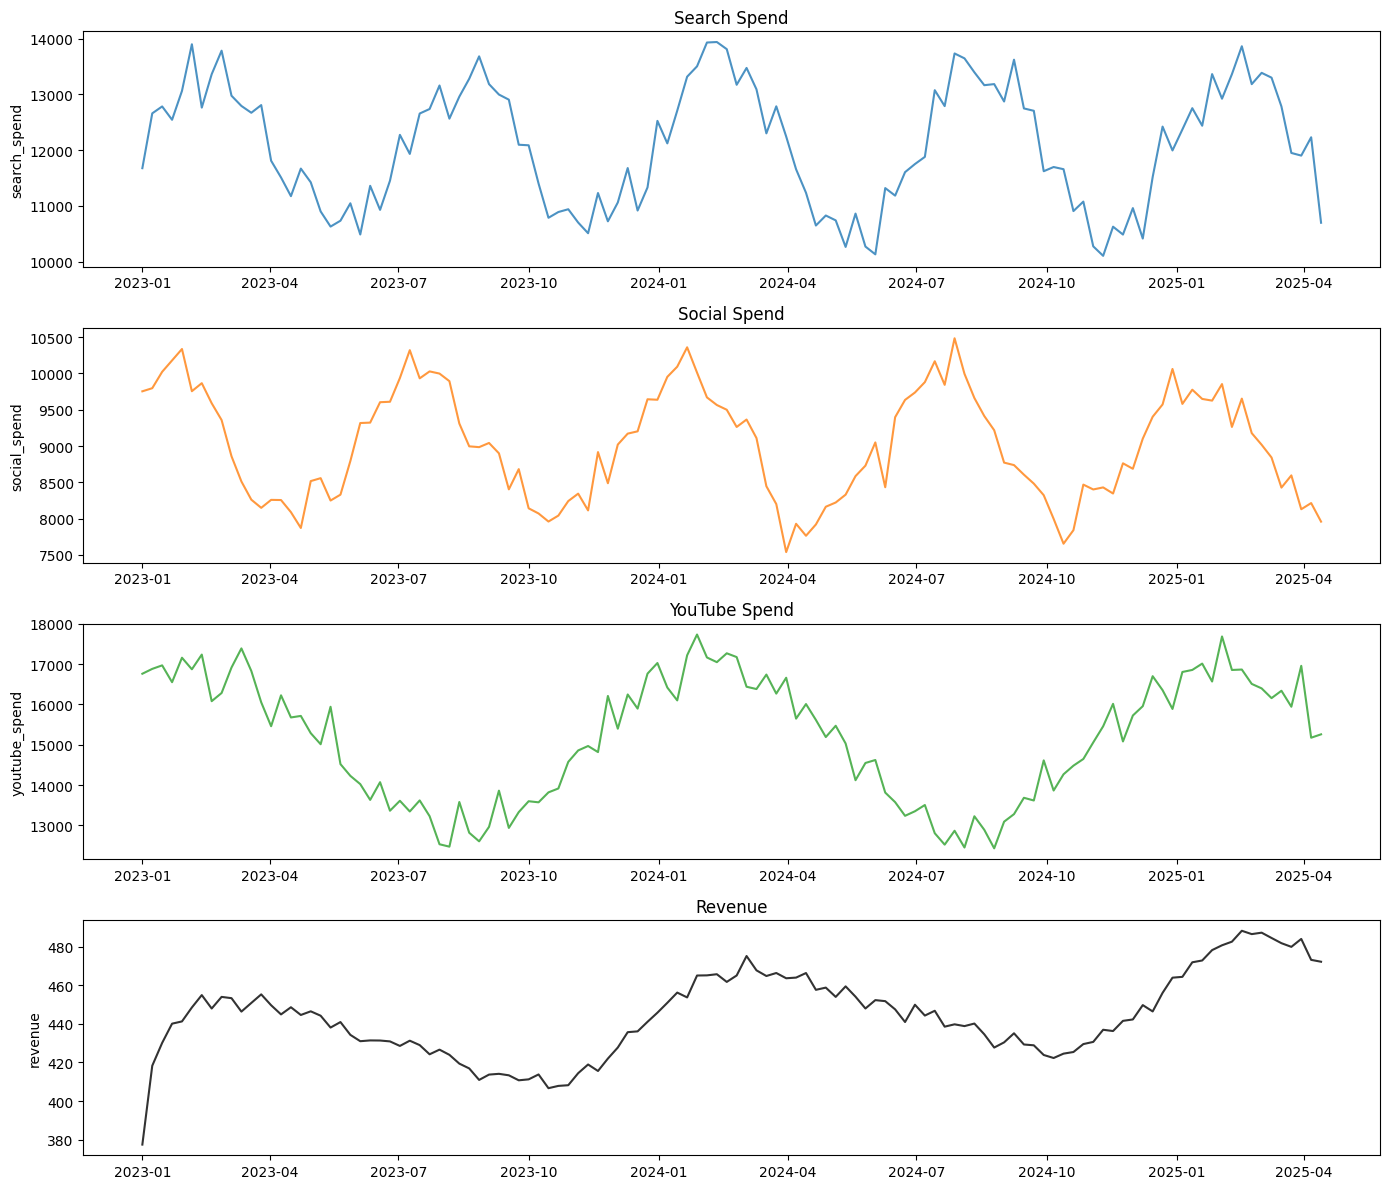

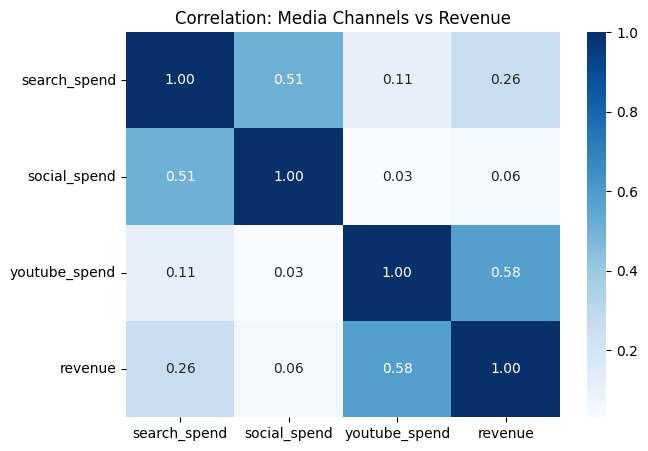

In [48]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

channels = ['search_spend', 'social_spend', 'youtube_spend', 'revenue']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#000000']
titles = ['Search Spend', 'Social Spend', 'YouTube Spend', 'Revenue']

for i, (col, color, title) in enumerate(zip(channels, colors, titles)):
    axes[i].plot(df_clean['date'], df_clean[col], color=color, alpha=0.8)
    axes[i].set_title(title)
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('eda_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df_clean[['search_spend','social_spend','youtube_spend','revenue']].corr(),
            annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation: Media Channels vs Revenue')
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
# If you have not already done this:
df_meridian = df_clean.copy()

# Meridian expects a time column and a KPI column.
df_meridian["time"] = df_meridian["date"].dt.strftime("%Y-%m-%d")
df_meridian["kpi"] = df_meridian["revenue"]

# For this toy project, we only have spend columns.
# As a simple portfolio approximation, use the spend columns as both media and media_spend.
channels = ["Search", "Social", "YouTube"]
df_meridian["search_media"] = df_meridian["search_spend"]
df_meridian["social_media"] = df_meridian["social_spend"]
df_meridian["youtube_media"] = df_meridian["youtube_spend"]

df_meridian[[
    "time", "kpi",
    "search_media", "social_media", "youtube_media",
    "search_spend", "social_spend", "youtube_spend"
]].head()

,time,kpi,search_media,social_media,youtube_media,search_spend,social_spend,youtube_spend
0,2023-01-01,377.435579,11674.310819,9754.037362,16762.317487,11674.310819,9754.037362,16762.317487
1,2023-01-08,418.282503,12658.177130,9796.989225,16882.777119,12658.177130,9796.989225,16882.777119
2,2023-01-15,430.120324,12781.978307,10022.895715,16970.020461,12781.978307,10022.895715,16970.020461
3,2023-01-22,440.068233,12542.795573,10179.762778,16552.160495,12542.795573,10179.762778,16552.160495
4,2023-01-29,441.234407,13060.895723,10337.188985,17159.768056,13060.895723,10337.188985,17159.768056


In [50]:
from meridian.data import data_frame_input_data_builder

builder = data_frame_input_data_builder.DataFrameInputDataBuilder(
    kpi_type="revenue",
    default_kpi_column="kpi"
)

builder = (
    builder.with_kpi(df_meridian, kpi_col="kpi", time_col="time")
           .with_media(
               df_meridian,
               media_cols=["search_media", "social_media", "youtube_media"],
               media_spend_cols=["search_spend", "social_spend", "youtube_spend"],
               media_channels=channels,
               time_col="time"
           )
)

data = builder.build()
print(data)

InputData(kpi=<xarray.DataArray 'kpi' (geo: 1, time: 120)> Size: 960B
array([[377.43557932, 418.28250285, 430.12032399, 440.06823298,
        441.23440704, 448.45635787, 454.87816834, 447.9111658 ,
        453.93952124, 453.27772044, 446.32064999, 450.80328958,
        455.24352986, 449.61531344, 444.86444482, 448.57296291,
        444.57549848, 446.46440584, 444.18780848, 438.05421497,
        440.90293134, 434.26893432, 430.98825996, 431.39162531,
        431.33989354, 430.88283094, 428.53400821, 431.25464781,
        428.96102469, 424.20489798, 426.62246645, 423.9274335 ,
        419.37544368, 416.88612872, 410.92990573, 413.69371446,
        414.08724956, 413.32182752, 410.73247252, 411.22365746,
        413.76204121, 406.64859043, 407.83655441, 408.18959686,
        414.42348021, 418.92472317, 415.56123045, 421.99387573,
        427.70321804, 435.6638915 , 436.08200368, 441.02784657,
        445.75137246, 450.87108758, 456.17173396, 453.666159  ,
        465.0103676 , 465.09142494

/usr/local/lib/python3.12/dist-packages/meridian/data/input_data.py:517: UserWarning: Revenue from the `kpi` data is used when `kpi_type`=`revenue`. `revenue_per_kpi` is ignored.
  warnings.warn(


In [51]:
import tensorflow_probability as tfp
from meridian import constants
from meridian.model import prior_distribution, spec
from meridian.model.model import Meridian

roi_mu = 0.2
roi_sigma = 0.9

prior = prior_distribution.PriorDistribution(
    roi_m=tfp.distributions.LogNormal(roi_mu, roi_sigma, name=constants.ROI_M)
)

model_spec = spec.ModelSpec(
    prior=prior,
    enable_aks=True
)

mmm = Meridian(input_data=data, model_spec=model_spec)
print(mmm)

/usr/local/lib/python3.12/dist-packages/meridian/model/model.py:75: UserWarning: In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.
  warnings.warn(


In [52]:
mmm.sample_prior(500)

mmm.sample_posterior(
    n_chains=4,
    n_adapt=1500,
    n_burnin=500,
    n_keep=1000,
    seed=42
)

/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1265: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. tau_g_excl_baseline has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1265: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_m has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1265: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_rf has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1265: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_om has been automatically se

In [53]:
from meridian.analysis.review import reviewer
print(dir(reviewer))

['CheckType', 'ChecksBattery', 'ConfigInstance', 'ModelReviewer', 'MutableMapping', '_HEALTH_SCORE_COMPONENTS', '_HealthScoreComponent', '_POST_CONVERGENCE_CHECKS', '__annotations__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_get_baseline_score', '_get_bayesian_ppp_score', '_get_gof_score', '_get_pps_score', '_get_roi_consistency_score', 'analyzer_module', 'checks', 'configs', 'constants', 'dataclasses', 'immutabledict', 'np', 'prior_distribution', 'results', 'review_constants', 'typing']


In [54]:
df2 = df[["date", "search_spend", "youtube_spend", "revenue"]].copy()
df2["time"] = pd.to_datetime(df2["date"]).dt.strftime("%Y-%m-%d")
df2["kpi"] = df2["revenue"]

df2["search_media"] = df2["search_spend"]
df2["youtube_media"] = df2["youtube_spend"]

In [55]:
from meridian.data import data_frame_input_data_builder

channels = ["Search", "YouTube"]

builder = data_frame_input_data_builder.DataFrameInputDataBuilder(
    kpi_type="revenue",
    default_kpi_column="kpi"
)

builder = (
    builder.with_kpi(df2, kpi_col="kpi", time_col="time")
           .with_media(
               df2,
               media_cols=["search_media", "youtube_media"],
               media_spend_cols=["search_spend", "youtube_spend"],
               media_channels=channels,
               time_col="time"
           )
)

data2 = builder.build()
print(data2)

InputData(kpi=<xarray.DataArray 'kpi' (geo: 1, time: 120)> Size: 960B
array([[377.43557932, 418.28250285, 430.12032399, 440.06823298,
        441.23440704, 448.45635787, 454.87816834, 447.9111658 ,
        453.93952124, 453.27772044, 446.32064999, 450.80328958,
        455.24352986, 449.61531344, 444.86444482, 448.57296291,
        444.57549848, 446.46440584, 444.18780848, 438.05421497,
        440.90293134, 434.26893432, 430.98825996, 431.39162531,
        431.33989354, 430.88283094, 428.53400821, 431.25464781,
        428.96102469, 424.20489798, 426.62246645, 423.9274335 ,
        419.37544368, 416.88612872, 410.92990573, 413.69371446,
        414.08724956, 413.32182752, 410.73247252, 411.22365746,
        413.76204121, 406.64859043, 407.83655441, 408.18959686,
        414.42348021, 418.92472317, 415.56123045, 421.99387573,
        427.70321804, 435.6638915 , 436.08200368, 441.02784657,
        445.75137246, 450.87108758, 456.17173396, 453.666159  ,
        465.0103676 , 465.09142494

/usr/local/lib/python3.12/dist-packages/meridian/data/input_data.py:517: UserWarning: Revenue from the `kpi` data is used when `kpi_type`=`revenue`. `revenue_per_kpi` is ignored.
  warnings.warn(


In [56]:
import tensorflow_probability as tfp
from meridian import constants
from meridian.model import prior_distribution, spec
from meridian.model.model import Meridian

roi_mu = 0.2
roi_sigma = 0.7

prior = prior_distribution.PriorDistribution(
    roi_m=tfp.distributions.LogNormal(roi_mu, roi_sigma, name=constants.ROI_M)
)

model_spec2 = spec.ModelSpec(
    prior=prior,
    enable_aks=False
)

mmm2 = Meridian(input_data=data2, model_spec=model_spec2)
print(mmm2)

/usr/local/lib/python3.12/dist-packages/meridian/model/model.py:75: UserWarning: In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.
  warnings.warn(


In [57]:
mmm2.sample_prior(300)

mmm2.sample_posterior(
    n_chains=4,
    n_adapt=1000,
    n_burnin=500,
    n_keep=800,
    seed=42
)

/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1265: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. tau_g_excl_baseline has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1265: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_m has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1265: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_rf has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1265: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_om has been automatically se

In [58]:
from meridian.analysis.review import reviewer

health_summary2 = reviewer.ModelReviewer(mmm2).run()
health_summary2

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:693: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(


Model Quality Checks
Overall Status: PASS
Summary: Passed with reviews: Review is needed.
Health Score: 81.4

Check Results:
----------------------------------------
Convergence Check:
  Status: PASS
  Recommendation: The model has likely converged, as all parameters have R-hat values < 1.2.
----------------------------------------
Baseline Check:
  Status: REVIEW
  Recommendation: The posterior probability that the baseline is negative is 0.25. This indicates that the baseline time series occasionally dips into negative values. We recommend visually inspecting the baseline time series in the Model Fit charts, but don't be overly concerned. An occasional, small dip may indicate minor statistical error, which is inherent in any model.
----------------------------------------
BayesianPPP Check:
  Status: PASS
  Recommendation: The Bayesian posterior predictive p-value is 0.98. The observed total outcome is consistent with the model's posterior predictive distribution.
-------------------

In [59]:
from meridian.analysis import visualizer

media_sum = visualizer.MediaSummary(mmm2)

print(dir(media_sum))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_analyzer', '_calculate_baseline_contribution_dataframe', '_calculate_contribution_dataframe', '_confidence_level', '_marginal_roi_by_reach', '_meridian', '_non_media_baseline_values', '_plot_metric_bar_chart', '_plot_roi_bubble_chart', '_selected_times', '_summary_metric_to_df', '_summary_metrics_to_mean_df', '_transform_contribution_spend_metrics', '_transform_media_metrics_for_roi_bubble_plot', '_use_kpi', 'all_summary_metrics', 'contribution_metrics', 'get_all_summary_metrics', 'get_paid_summary_metrics', 'paid_summary_metrics', 'plot_channel_contribution_area_chart', 'plot_channel_contribution_bump_chart', 'plot_contribution_

In [60]:
contrib = media_sum.contribution_metrics(aggregate_times=True)
contrib

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1031: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  warnings.warn(


,channel,incremental_outcome,pct_of_contribution
2,YouTube,26348.482422,0.494523
1,Search,22280.082031,0.418165
0,baseline,4652.073730,0.087313


In [64]:
contrib = media_sum.contribution_metrics(aggregate_times=True)
contrib

,channel,incremental_outcome,pct_of_contribution
2,YouTube,26348.482422,0.494523
1,Search,22280.082031,0.418165
0,baseline,4652.073730,0.087313


In [65]:
contrib.to_csv("channel_contribution.csv", index=False)

In [77]:
chart = media_sum.plot_channel_contribution_area_chart()
chart


alt.Chart(...)

In [78]:
chart.save("contribution_plot.html")

In [74]:
fit.plot_model_fit()

import matplotlib.pyplot as plt
plt.savefig("model_fit.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [69]:
fit.plot_model_fit()

alt.LayerChart(...)

In [70]:
import os
print(os.listdir())

['.config', 'eda_trends.png', 'contribution_plot.html', 'simulated_mmm_data_.csv', 'correlation_heatmap.png', 'simulated_mmm_data_ (1).csv', 'channel_contribution.csv', 'sample_data']
